In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Path dos dados
# Base fipe historica
fipe_path = 'fipe_2022.csv'
# Base da taxa de cambio
exchange_path = 'DEXBZUS.csv'
# Base IPCA
ipca_path = 'bcdata.sgs.433.csv' 
# Adicionar PIB

df_fipe = pd.read_csv(fipe_path)
print('FIPE shape:', df_fipe.shape)
print(df_fipe.head())

df_ex = pd.read_csv(exchange_path)
print('DEXBZUS head:')
print(df_ex.head())

df_ipca = pd.read_csv(ipca_path, sep=';', decimal=',')
print('IPCA head:')
print(df_ipca.head())

FIPE shape: (290275, 12)
   year_of_reference month_of_reference fipe_code authentication  brand  \
0               2022            January  038001-6     vwmrywl5qs  Acura   
1               2022            January  038001-6     t9mt723qhz  Acura   
2               2022            January  038001-6     tr5wv4z21g  Acura   
3               2022            January  038001-6     s2xxsjz3mt  Acura   
4               2022            January  038001-6     rtm9gj7zk8  Acura   

     model      fuel    gear  engine_size  year_model  avg_price_brl  \
0  NSX 3.0  Gasoline  manual          3.0        1995        43779.0   
1  NSX 3.0  Gasoline  manual          3.0        1994        42244.0   
2  NSX 3.0  Gasoline  manual          3.0        1993        40841.0   
3  NSX 3.0  Gasoline  manual          3.0        1992        39028.0   
4  NSX 3.0  Gasoline  manual          3.0        1991        35678.0   

   age_years  
0         28  
1         29  
2         30  
3         31  
4         32  
D

In [ ]:

# --- Limpeza FIPE ---
# Converte nomes de meses para números
month_map = {'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
             'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12}

df_fipe['month_num'] = df_fipe['month_of_reference'].map(month_map)
# Cria coluna de data (primeiro dia do mes)
df_fipe['date'] = pd.to_datetime(df_fipe['year_of_reference'].astype(str) + '-' + df_fipe['month_num'].astype(str) + '-01')

duplicates = df_fipe.duplicated().sum()
missing = df_fipe.isnull().sum()
print('Duplicados FIPE:', duplicates)
print('Valores ausentes FIPE:', missing)

# --- Limpeza taxa de cambio ---
if 'observation_date' in df_ex.columns:
    df_ex['date'] = pd.to_datetime(df_ex['observation_date'])
else:
    df_ex['date'] = pd.to_datetime(df_ex.iloc[:, 0])

exchange_col = [col for col in df_ex.columns if col not in ['date','observation_date']][0]
df_ex[exchange_col] = pd.to_numeric(df_ex[exchange_col], errors='coerce')

df_ex['date'] = pd.to_datetime(df_ex['observation_date'])

df_ex['DEXBZUS'] = pd.to_numeric(df_ex['DEXBZUS'], errors='coerce')

# Agrega para fazer a media mensal
df_ex_monthly = (
    df_ex[['date', 'DEXBZUS']]
    .set_index('date')
    .resample('ME')
    .mean()
    .reset_index()
)
df_ex_monthly.rename(columns={'DEXBZUS': 'exchange_rate'}, inplace=True)

# --- Limpeza IPCA ---
if df_ipca.columns.tolist()[0].strip().lower() == '"data"' or 'data' in df_ipca.columns[0]:
    df_ipca.columns = ['data','valor']
try:
    df_ipca['date'] = pd.to_datetime(df_ipca['data'], dayfirst=True)
except:
    df_ipca['date'] = pd.to_datetime(df_ipca['data'].str.replace('"',''), dayfirst=True)
df_ipca['ipca'] = df_ipca['valor'].astype(str).str.replace('"','').str.replace('.', '')
df_ipca['ipca'] = df_ipca['ipca'].str.replace(',', '.').astype(float)
df_ipca_monthly = df_ipca[['date','ipca']].copy()
df_ipca_monthly['date'] = df_ipca_monthly['date'].dt.to_period('M').dt.to_timestamp('M')

print('Amostra IPCA mensal:')
print(df_ipca_monthly.head())

Duplicados FIPE: 2
Valores ausentes FIPE: year_of_reference     0
month_of_reference    0
fipe_code             0
authentication        0
brand                 0
model                 0
fuel                  0
gear                  0
engine_size           0
year_model            0
avg_price_brl         0
age_years             0
month_num             0
date                  0
dtype: int64
Amostra IPCA mensal:
        date   ipca
0 1980-01-31  662.0
1 1980-02-29  462.0
2 1980-03-31  604.0
3 1980-04-30  529.0
4 1980-05-31   57.0


In [17]:

# Alinha variaveis macroeconomicas para o mesmo periodo
# Ajusta datas para fim do mes no FIPE para combinar mais facilmente com IPCA e cambio
fipe_monthly = df_fipe.copy()
fipe_monthly['date'] = fipe_monthly['date'].dt.to_period('M').dt.to_timestamp('M')

# Junta com taxa de cambio
merged = fipe_monthly.merge(df_ex_monthly, on='date', how='left')

# Junta com IPCA
merged = merged.merge(df_ipca_monthly, on='date', how='left')

merged.drop(columns=['month_of_reference','month_num'], inplace=True)

print('Shape merged:', merged.shape)
print(merged[['date','brand','model','avg_price_brl','exchange_rate','ipca']].head())

# Retira linhas sem preço ou variaveis macro
merged = merged.dropna(subset=['avg_price_brl','exchange_rate','ipca'])

Shape merged: (290275, 14)
        date  brand    model  avg_price_brl  exchange_rate  ipca
0 2022-01-31  Acura  NSX 3.0        43779.0       5.530045  54.0
1 2022-01-31  Acura  NSX 3.0        42244.0       5.530045  54.0
2 2022-01-31  Acura  NSX 3.0        40841.0       5.530045  54.0
3 2022-01-31  Acura  NSX 3.0        39028.0       5.530045  54.0
4 2022-01-31  Acura  NSX 3.0        35678.0       5.530045  54.0


Distribuição de preços (R$):
count    281114.000000
mean      82340.128862
std      101156.279777
min        1831.000000
25%       21241.000000
50%       44786.000000
75%       96926.000000
max      599989.000000
Name: avg_price_brl, dtype: float64
Top 10 marcas por número de registros:
                          mean  count
brand                                
GM - Chevrolet    52055.898945  28143
VW - VolksWagen   42277.323467  28142
Fiat              39877.096864  26563
Ford              49464.187992  24150
Mercedes-Benz    174320.318655  16124
Renault           47600.900224  15194
Audi             136825.561783  11597
Peugeot           41519.542939  11132
Toyota            92086.817538  10309
Mitsubishi        85786.164113  10182


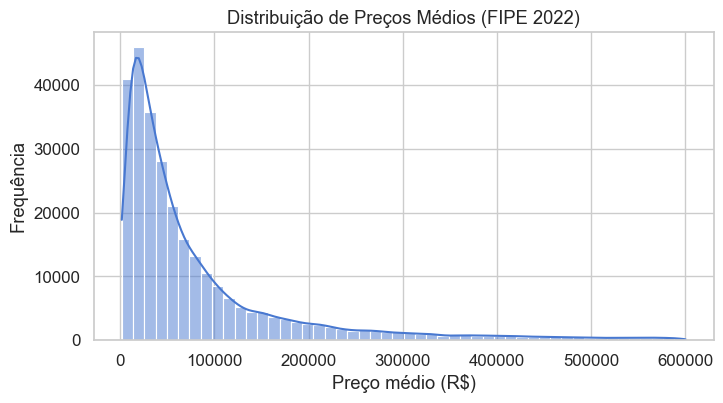

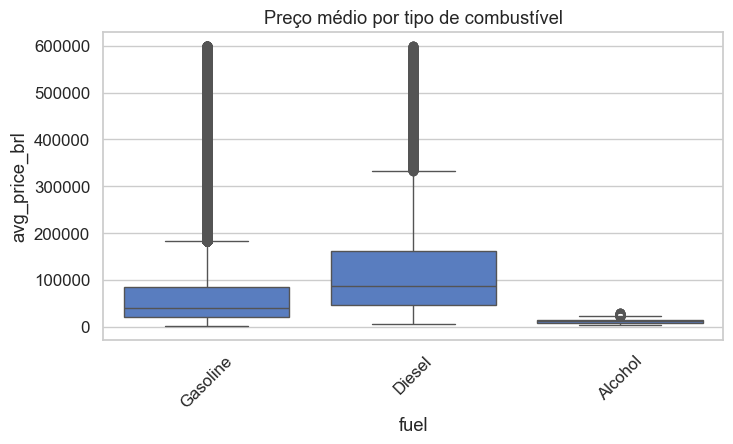

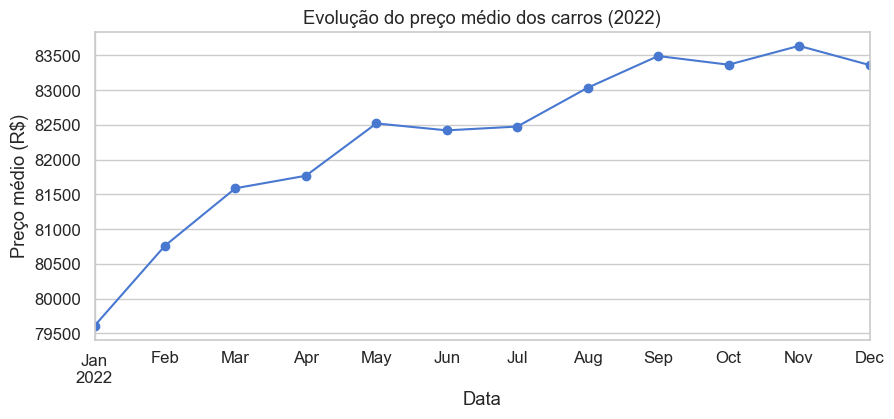

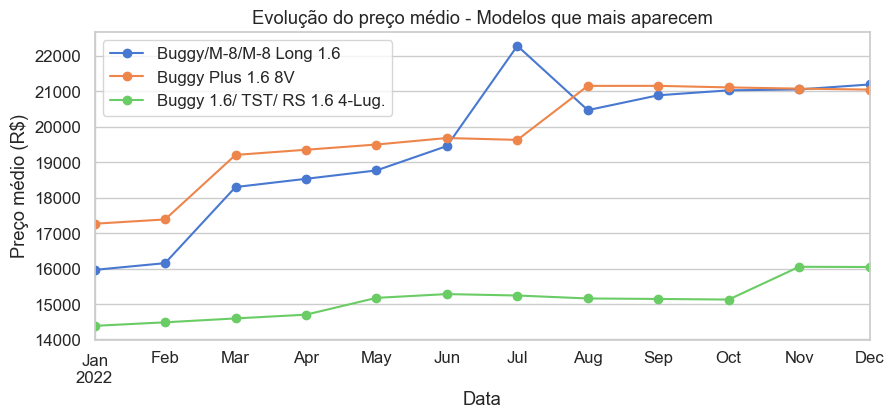

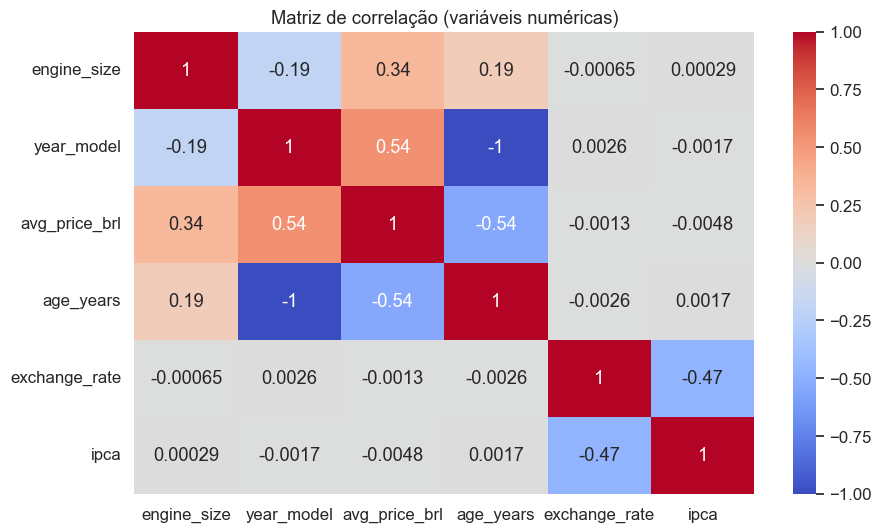

In [ ]:

# Estatisticas descritivas
print('Distribuição de preços (R$):')
print(merged['avg_price_brl'].describe())

# Distribuicao por marca
brand_stats = merged.groupby('brand')['avg_price_brl'].agg(['mean','count']).sort_values('count', ascending=False).head(10)
print('Top 10 marcas por número de registros:')
print(brand_stats)

# Histograma do preco medio
plt.figure(figsize=(8,4))
sns.histplot(merged['avg_price_brl'], bins=50, kde=True)
plt.title('Distribuição de Preços Médios (FIPE 2022)')
plt.xlabel('Preço médio (R$)')
plt.ylabel('Frequência')
plt.show()

# Boxplot por categoria de combustivel
plt.figure(figsize=(8,4))
sns.boxplot(x='fuel', y='avg_price_brl', data=merged)
plt.title('Preço médio por tipo de combustível')
plt.xticks(rotation=45)
plt.show()

# Evolucao temporal media
plt.figure(figsize=(10,4))
merged.groupby('date')['avg_price_brl'].mean().plot(marker='o')
plt.title('Evolução do preço médio dos carros (2022)')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.show()

# Evolucao dos 3 modelos que mais aparecem
top_models = merged['model'].value_counts().head(3).index.tolist()
plt.figure(figsize=(10,4))
for m in top_models:
    subset = merged[merged['model']==m]
    subset.groupby('date')['avg_price_brl'].mean().plot(marker='o', label=m)
plt.title('Evolução do preço médio - Modelos que mais aparecem')
plt.xlabel('Data')
plt.ylabel('Preço médio (R$)')
plt.legend()
plt.show()

# Correlacao variaveis numericas
num_cols = ['engine_size','year_model','avg_price_brl','age_years','exchange_rate','ipca']
corr = merged[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlação (variáveis numéricas)')
plt.show()